In [56]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier  ## pour le model de classification 
from sklearn.linear_model import LinearRegression #  Pour la regression lineairw
from sklearn.model_selection import train_test_split   # Pour la separation des donnnes du test et d'entrainment

In [57]:
##Classification est  un  model qui est utiliser pour entrainer des categories de donnes 

# 1-) Regression linaire

In [58]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [59]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


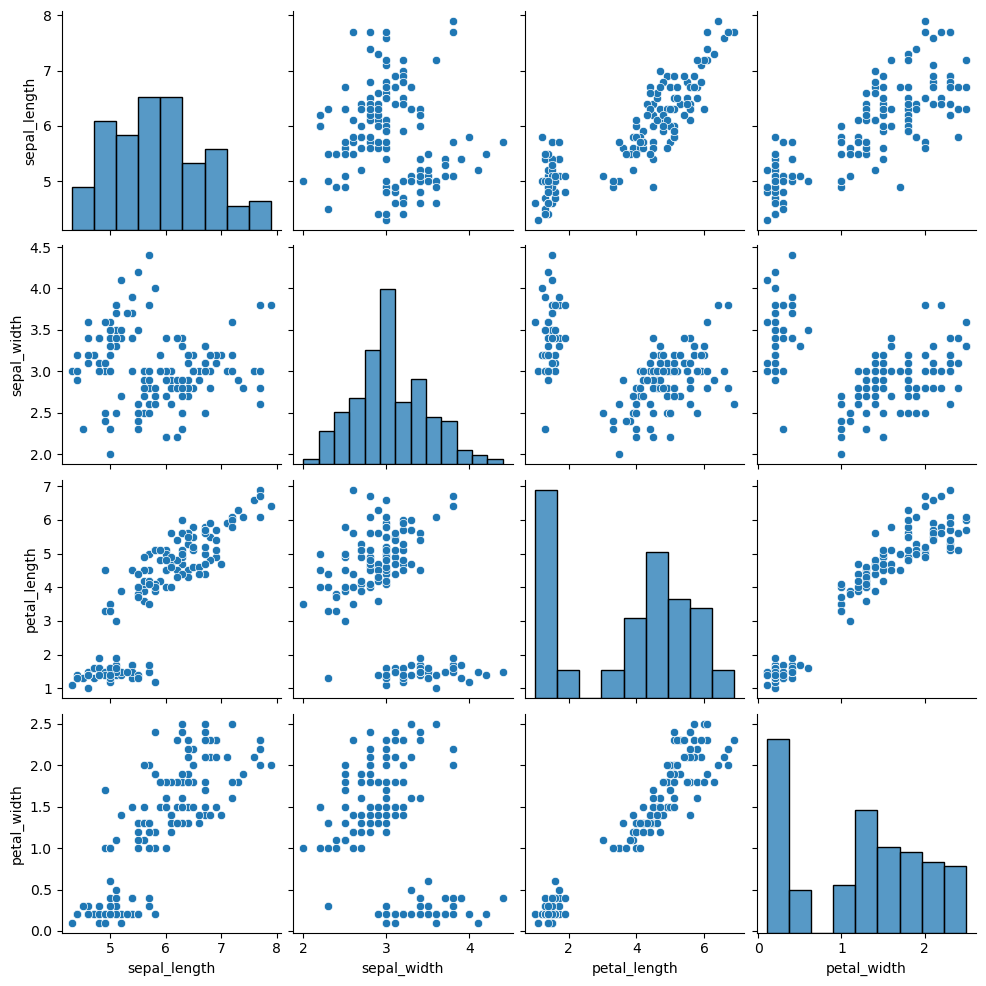

In [60]:
sns.pairplot(iris)

<Axes: xlabel='petal_length', ylabel='petal_width'>

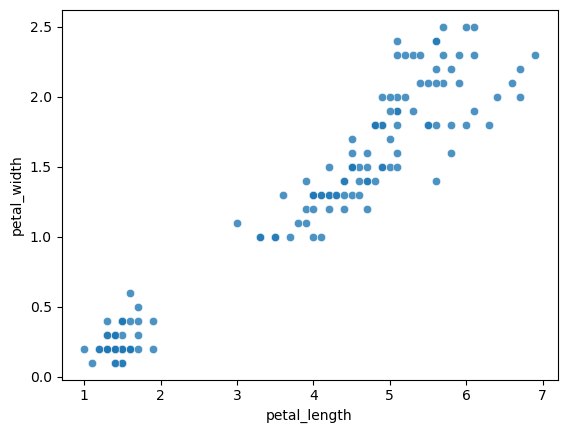

In [61]:
sns.scatterplot(data = iris , x = "petal_length", y = "petal_width", alpha = 0.8)

In [62]:
y= iris["petal_length"]
X = iris[["petal_width", "sepal_width", "sepal_length"]]

In [63]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [64]:
model = LinearRegression()
model.fit(X_train, y_train)  #Entrainement du model 
model.score(X_train, y_train)

0.9698225247940602

In [65]:
model.score(X_test, y_test)

0.9603293155857664

In [66]:
print(f"Entrainement : {model.score(X_train, y_train)}")
print(f"Evaluation   : {model.score(X_test, y_test)}")

Entrainement : 0.9698225247940602
Evaluation   : 0.9603293155857664


In [67]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv = 5)
print(f"Score moyen : {scores.mean()}")

Score moyen : 0.28469900184144536


## Classifiacation

In [87]:
titanic = sns.load_dataset("titanic")

In [88]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [89]:
titanic = titanic[["survived", "sex","pclass", "age"]]
titanic.head()

,survived,sex,pclass,age
0,0,male,3,22.0
1,1,female,1,38.0
2,1,female,3,26.0
3,1,female,1,35.0
4,0,male,3,35.0


In [91]:
titanic["sex"] = titanic["sex"].replace({
    "female" : 1,
    "male" : 0
})
titanic.dropna(axis = 0, inplace = True)

In [92]:
titanic.head()

,survived,sex,pclass,age
0,0,0,3,22.0
1,1,1,1,38.0
2,1,1,3,26.0
3,1,1,1,35.0
4,0,0,3,35.0


In [93]:
print(f"Nombre de lignes : {titanic.shape[0]}\n\n")
titanic.info()

Nombre de lignes : 714


<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   sex       714 non-null    int64  
 2   pclass    714 non-null    int64  
 3   age       714 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 27.9 KB


In [94]:
titanic.shape[0]

714

In [95]:
titanic["age"] = titanic["age"].astype(int)

In [96]:
titanic.head()

,survived,sex,pclass,age
0,0,0,3,22
1,1,1,1,38
2,1,1,3,26
3,1,1,1,35
4,0,0,3,35


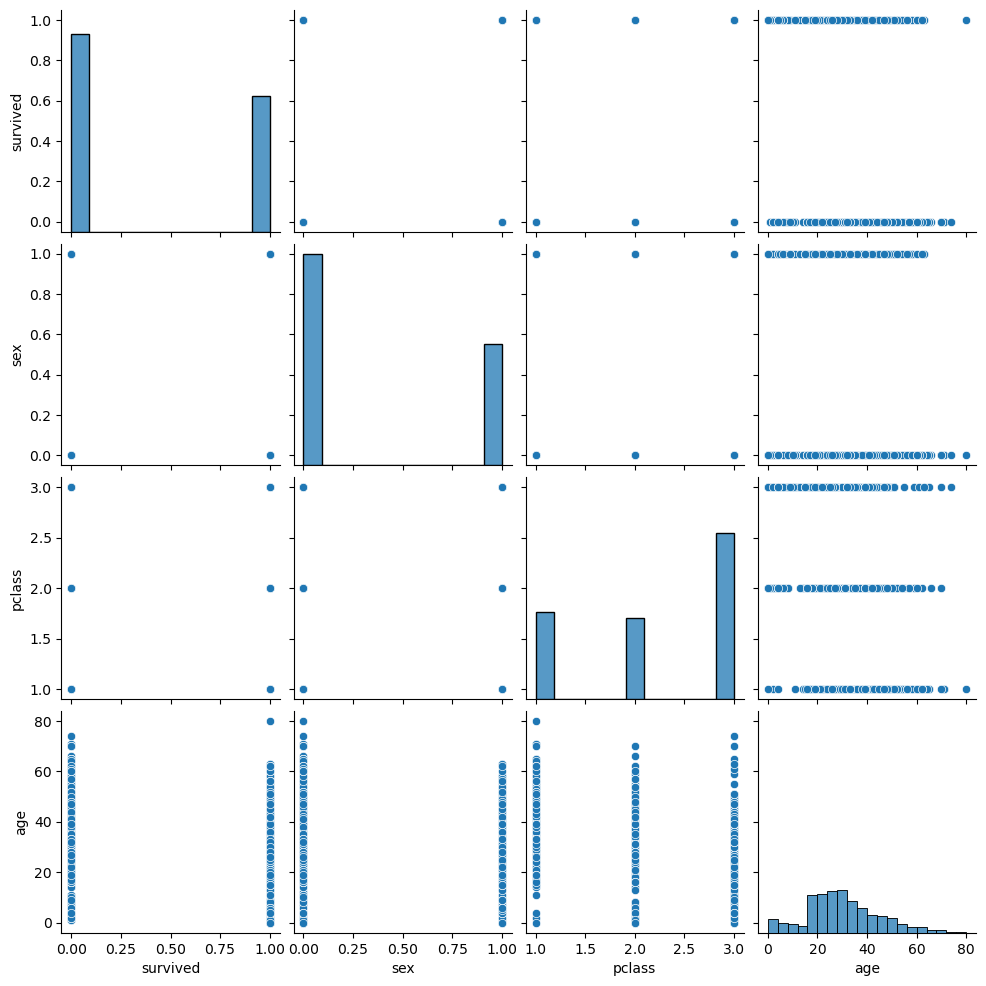

In [97]:
sns.pairplot(titanic)

<Axes: >

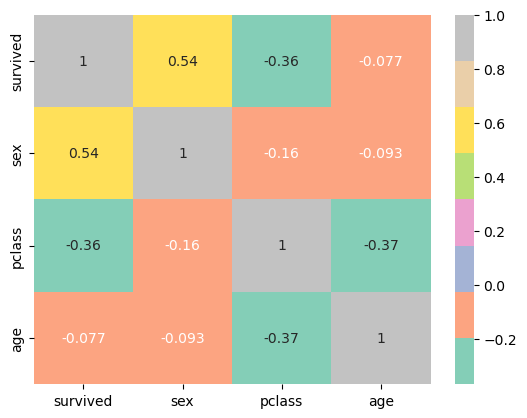

In [98]:
sns.heatmap(titanic.corr(numeric_only = True), alpha = 0.8, annot= True, cmap = "Set2")

In [99]:
X = titanic[["age", "sex", "pclass"]]   
y = titanic["survived"]              

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
model = KNeighborsClassifier(n_neighbors =1)
model.fit(X, y)
res = model.score(X_train, y_train)

In [101]:
print(f"Entrainement :{round(res, 2)*100 }%")

Entrainement :86.0%


In [102]:
score = cross_val_score(model, X, y, cv = 5)
score

array([0.72027972, 0.76223776, 0.78321678, 0.76923077, 0.73943662])

In [103]:
score_model = score.mean()
print(f"Test_val : {score_model.round(2)*100} %")

Test_val : 75.0 %


In [104]:
r = model.score(X_test, y_test)

In [105]:
print(f"Entrainement finale : {round(r, 2)*100}%")

Entrainement finale : 84.0%


## Les fleurs d'iris

In [106]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


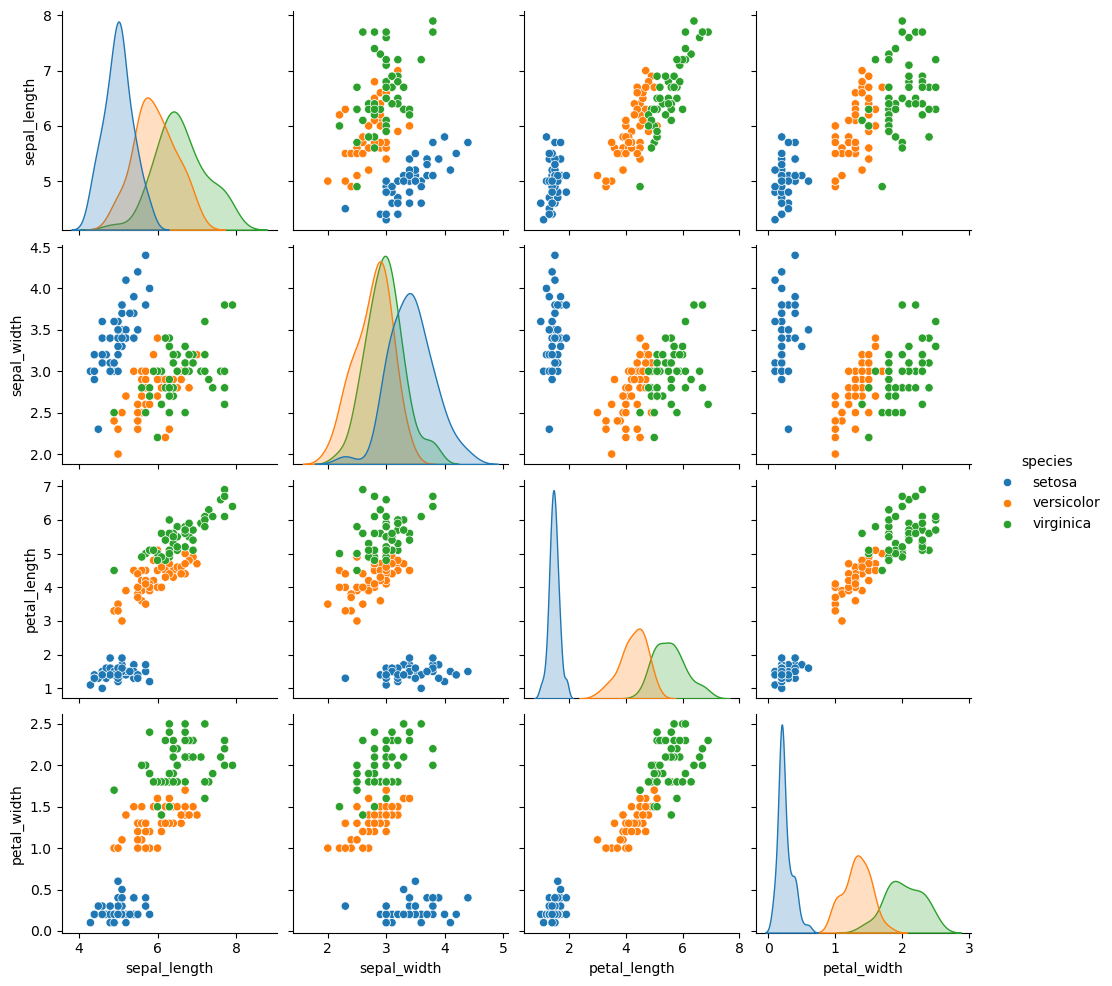

In [108]:
sns.pairplot(iris, hue = "species")

In [199]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

In [200]:
X =iris[["sepal_length", "sepal_width",	"petal_length",	"petal_width"]]
y = iris["species"]

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.2, random_state  = 5)

In [202]:
print(f"Donnnes Entrainement : {X_train.shape}")
print(f"Donnees D'evaluation  : {X_test.shape}")

Donnnes Entrainement : (120, 4)
Donnees D'evaluation  : (30, 4)


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

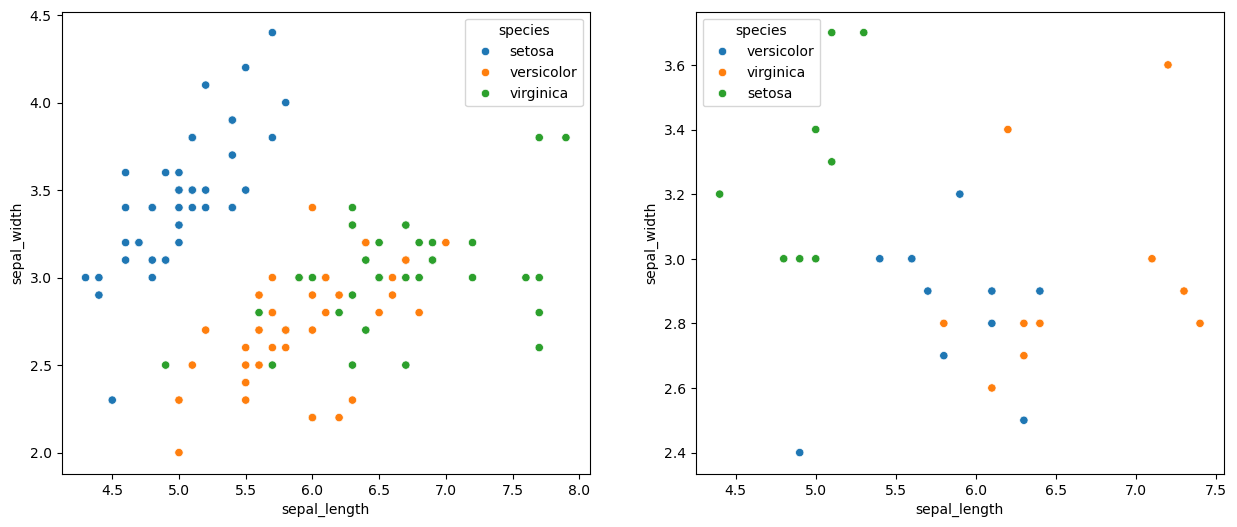

In [203]:
plt.figure(figsize = (15, 6))
plt.subplot(1,2,1)
sns.scatterplot(data = X_train,x ="sepal_length", y = "sepal_width", hue =y_train) 
plt.subplot(1,2,2)
sns.scatterplot(data = X_test,x ="sepal_length", y = "sepal_width", hue =y_test) 

In [207]:
model = KNeighborsClassifier (n_neighbors = 6) # Reglage et optimiation
model.fit(X_train, y_train)
resultat_score = model.score(X_train, y_train) 

print(f"\nScore a l'entrainement du model :{round(resultat_score*100, 2)}%\n")


Score a l'entrainement du model :98.33%



<h4 style="color : blue">Validation set</h3>

- On utilise un validation set pour vérifier si le modèle fonctionne bien sur des données qu’il n’a pas vues pendant son entraînement, et surtout pour choisir les meilleurs paramètres du modèle avant l’évaluation finale.

<h3 style = "color : blue">Cross validation</h3>


- La cross-validation est utilisée pour évaluer un modèle de manière plus fiable. Au lieu de séparer les données une seule fois en entraînement et        test, on les divise en plusieurs parties et on entraîne le modèle plusieurs fois. À chaque fois, une partie différente sert à la validation. Ensuite,   on calcule la moyenne des résultats.

     En gros, elle permet de vérifier que les performances du modèle ne dépendent pas simplement d’un seul découpage des données.

In [208]:
from sklearn.model_selection import cross_val_score # importation du module 

In [245]:
data_valide = cross_val_score(KNeighborsClassifier(), X_train, y_train, cv = 5, scoring = "accuracy")

In [246]:
print(f"Score de validation : {round(data_valide.mean(), 2)}")

Score de validation : 0.98


Text(0, 0.5, 'Score')

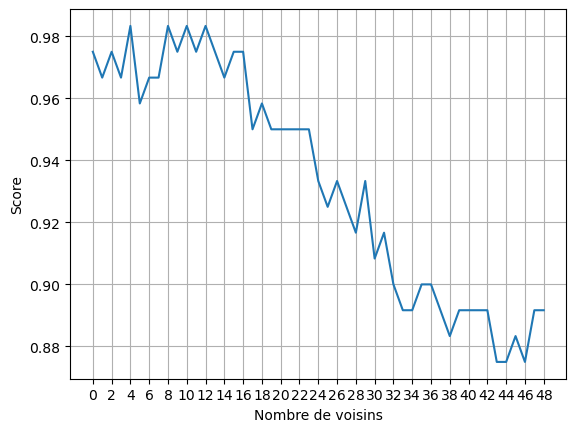

In [250]:
val_score = []
for i in range(1, 50):
    resultat  = cross_val_score(KNeighborsClassifier(n_neighbors = i), X_train, y_train, cv = 5).mean()
    val_score.append(resultat)

plt.plot(val_score)
plt.grid()
plt.xticks(ticks = np.arange(0, 50, 2))
plt.xlabel("Nombre de voisins")
plt.ylabel("Score")

<h3 style = "color : blue">Validation Curve</h3>

La Validation Curve sert à voir comment les performances d’un modèle évoluent lorsque l’on change un paramètre.

Par exemple, avec KNN, on peut tester plusieurs valeurs de n_neighbors : 1, 3, 5, 7, 10…

On observe ensuite les scores d’entraînement et de validation.

Elle permet donc de trouver une bonne valeur du paramètre et de détecter si le modèle fait du sous-apprentissage ou du surapprentissage.

In [267]:
from sklearn.model_selection import validation_curve

model = KNeighborsClassifier()
k = np.arange(1, 50) # l'iterateur
train_score, val_score = validation_curve(model, X_train, y_train,
                                          param_name = "n_neighbors", param_range = k, cv = 5)
#Chaque ligne  de val_score contient les 5 score de valiation 
moyenne_score_val  = val_score.mean(axis = 1)
moyenne_score_train = train_score.mean(axis = 1)
moyenne_score

print(f"Donnees de l'entrainment :\n{moyenne_score_train}\n\nDonnees de validadtion :\n {moyenne_score_val}\n")

Donnees de l'entrainment :
[1.         0.98333333 0.97916667 0.97708333 0.98125    0.975
 0.97708333 0.97291667 0.97708333 0.975      0.97708333 0.97291667
 0.97708333 0.97291667 0.975      0.96666667 0.96666667 0.9625
 0.96041667 0.95625    0.95833333 0.95833333 0.96041667 0.95625
 0.95833333 0.95208333 0.95       0.93541667 0.93958333 0.93541667
 0.93958333 0.93125    0.92291667 0.91666667 0.925      0.91666667
 0.9125     0.91458333 0.91666667 0.91458333 0.91041667 0.91041667
 0.90625    0.89583333 0.90208333 0.90208333 0.90416667 0.89791667
 0.89791667]

Donnees de validadtion :
 [0.975      0.96666667 0.975      0.96666667 0.98333333 0.95833333
 0.96666667 0.96666667 0.98333333 0.975      0.98333333 0.975
 0.98333333 0.975      0.96666667 0.975      0.975      0.95
 0.95833333 0.95       0.95       0.95       0.95       0.95
 0.93333333 0.925      0.93333333 0.925      0.91666667 0.93333333
 0.90833333 0.91666667 0.9        0.89166667 0.89166667 0.9
 0.9        0.89166667 0.883333

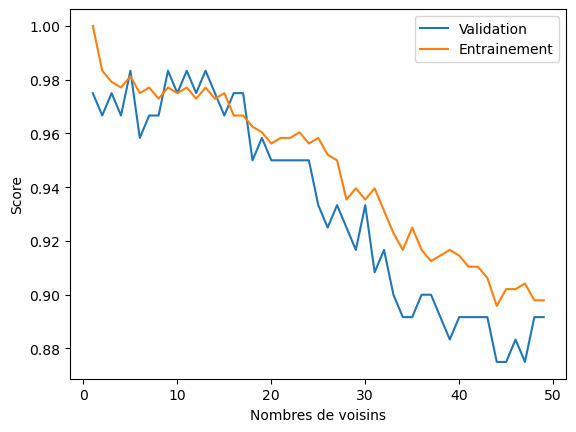

In [269]:
plt.plot(k, moyenne_score_val, label = "Validation") # On retrouve le meme avec celui avec range
plt.plot(k, moyenne_score_train, label = "Entrainement")
plt.ylabel("Score")
plt.xlabel("Nombres de voisins")
plt.legend()

Avec ce grapiphique on sait desormains qu'on peut atteindre 98% de performance en choisissant la bonne valeur pour l'hyper_parametre ***n_neighbors*** 

<h3 style = "color : blue">Overfeting</h3>

Dans le cas du surapprentissage (overfitting), le modèle apprend trop bien les données d’entraînement, jusqu’à mémoriser leurs particularités et leurs erreurs.

Par exemple, si le score d’entraînement est 98 % mais que le score de validation est seulement 65 %, cela signifie que le modèle fonctionne très bien sur les données qu’il connaît, mais mal sur de nouvelles données.

La Validation Curve permet justement de repérer ce problème en comparant le score d’entraînement et le score de validation

<h3 style = "color : blue">GridSearchCV</h3>

***GridSearchCV*** est utilisé pour trouver automatiquement les meilleurs paramètres d’un modèle.

Par exemple, avec KNN, tu peux tester plusieurs valeurs de n_neighbors comme 3, 5, 7, 9. GridSearchCV teste différentes combinaisons de paramètres avec la validation croisée, puis sélectionne celle qui donne le meilleur score.

En gros : GridSearchCV = tester plusieurs réglages + validation croisée + choisir le meilleur réglage.

In [271]:
from sklearn.model_selection import GridSearchCV